In [141]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import argparse
import numpy as np
import random
import scipy
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.stats import kendalltau
import pandas as pd

In [143]:
edges=np.genfromtxt("Euroroads.txt",dtype=int)
edge_index=edges
edges=edges
print(edges.shape)
adj = sp.coo_matrix((np.ones(edges.shape[0]), (edges[:, 0]-1, edges[:, 1]-1)),
                        shape=(1174, 1174))
adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)
adj_Euroroads = torch.FloatTensor(np.array(adj.todense()))
print(adj_Euroroads)
adj=np.array(adj_Euroroads)
G_Euroroads = nx.Graph()
G_Euroroads = nx.from_numpy_array(adj)
list_Euroroads=list(range(1174))

(1417, 2)
tensor([[0., 1., 0.,  ..., 0., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.]])


In [145]:
def min_max_normalization(tensor):
    # 找出数组的最小值和最大值
    min_val = torch.min(tensor)
    max_val = torch.max(tensor)

    # 进行最小 - 最大标准化
    normalized_tensor = (tensor - min_val) / (max_val - min_val)
    return normalized_tensor
# node_feature_BA = min_max_normalization(node_feature_BA)
# node_feature_BA1 = min_max_normalization(node_feature_BA1)


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

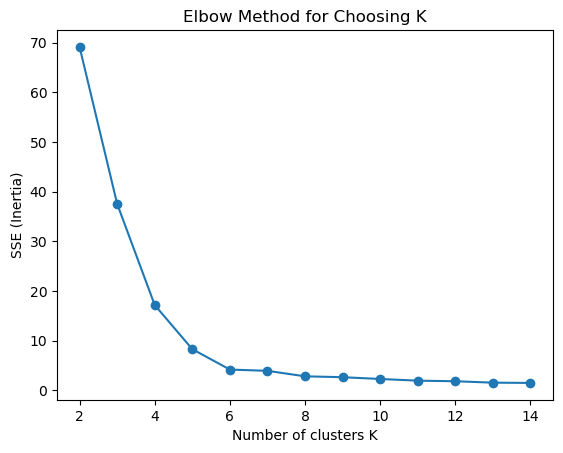

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 假设你的特征矩阵叫 node_feature_vidal
X = node_feature_Euroroads.detach().numpy()

# 1. 肘部法则（Elbow Method）
sse = []
k_list = range(2, 15)  # 尝试K从2到14
for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_就是SSE

plt.figure()
plt.plot(k_list, sse, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Choosing K')
plt.show()

In [255]:
class GNN(torch.nn.Module):
    def __init__(self,input_feature,output_feature):
        super(GNN,self).__init__()
        self.w = nn.Parameter(torch.empty(size=(input_feature,output_feature)))
        self.a= nn.Parameter(torch.empty(size=(1,output_feature)))
        self.sigmod=torch.nn.Sigmoid()
        self.reset_parameters()
    def reset_parameters(self):
        #nn.init.xavier_uniform_(self.w.data,gain=1.414)
        #nn.init.xavier_uniform_(self.a.data,gain=1.414)
        for param in self.parameters():
             nn.init.xavier_uniform_(param)
        
    def forward(self,x,adj):
        adj=torch.Tensor(adj.numpy()+np.identity(adj.shape[0]))
        # adj=torch.FloatTensor(normalize_adj(sp.csr_matrix(adj)+ sp.eye(adj.shape[0])).todense())
        x=torch.mm(adj,x)
        x=torch.mm(x,self.w)
        x=x.add(self.a)
        x=torch.relu(x)
        return x


class CGNN(torch.nn.Module):
    def __init__(self):
        super(CGNN,self).__init__()
        self.layer2=GNN(48,6)
        self.layer3=GNN(6,12)
        # self.fc1=torch.nn.Linear(6,12)
        self.fc1=torch.nn.Linear(12,1)
        # self.fc2=torch.nn.Linear(24,1)
        
        
       
     
    
    
    def forward(self,x,adj,target_nodes):
        #x=self.layer1(x)
        # x=torch.cat([x1,x],dim=-1)
        # x=0.5*x+0.5*x1
        x=self.layer2(x,adj)
        x=self.layer3(x,adj)
       # x=self.layer4(x,adj)
        
        x=x[target_nodes]
        
        x=self.fc1(x.view(x.size(0),-1))
        x=torch.relu(x)
        # x=self.fc2(x)
        # x=torch.relu(x)
        x=x.flatten()
        
        return x

In [213]:
# {'learning_rate': 0.001, 'epochs': 1900, 'epoch_1': 300, 'learning_rate1': 0.005}
#最佳参数组合: {'learning_rate': 0.009000000000000001, 'epochs': 1400, 'epoch_1': 200, 'learning_rate1': 0.005}
# 最小RMSE: 0.8009
# 最佳参数组合: {'learning_rate': 0.017, 'epochs': 356, 'epoch_1': 300, 'learning_rate1': 0.005}
# 最小RMSE: 0.8387
# 最佳试验编号: 32

# 最佳参数组合: {'learning_rate': 0.002, 'epochs': 971, 'epoch_1': 300, 'learning_rate1': 0.005}
# 最小RMSE: 0.8754
# 最佳试验编号: 125

In [277]:
lable_Euroroads=np.load("lable/lable_Euroroads.npy")
lable_Euroroads_t=torch.tensor(lable_Euroroads).float()
node_feature_Euroroads=torch.load("EC做损失的特征向量/node_feature_Euroroads_LSTM_EC_0.001_100.pt")
node_feature_Euroroads = min_max_normalization(node_feature_Euroroads)

In [279]:
import numpy as np
from sklearn.cluster import KMeans
# 假设 node_feature_jazz 是你的节点特征矩阵，形状是 (num_nodes, feature_dim)
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
    
# 设置聚类数量
k = 4
X = node_feature_Euroroads.detach().numpy()

# 执行 KMeans 聚类
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
cluster_nodes = {i: [] for i in range(k)}
for idx, label in enumerate(labels):
    cluster_nodes[label].append(idx)
#选择训练集的节点
n_nodes = node_feature_Euroroads.shape[0]

# 1. 随机采样 5% 的节点索引
num_train = int(0.05 * n_nodes)+1

train_idx=[]
while len(train_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            train_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(train_idx) >= num_train:
                break

pinggu_idx=[]
while len(pinggu_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            pinggu_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(pinggu_idx) >= num_train:
                break

# 2. 构造训练集（只选取部分节点特征）
train_Euroroads = node_feature_Euroroads[train_idx]
train_Euroroads_lable = lable_Euroroads_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
    
pinggu_Euroroads = node_feature_Euroroads[pinggu_idx]
pinggu_Euroroads_lable = lable_Euroroads_t[pinggu_idx]

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [281]:
import time
import numpy as np
import torch
import torch.optim as optim
from scipy.stats import kendalltau

# 确保随机种子完全一致
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
# 对于CUDA环境，还需固定cuda随机种子
if torch.cuda.is_available():
    torch.cuda.manual_seed(17)
    torch.cuda.manual_seed_all(17)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train(epoch, model, optimizer, node_feature, adj, train_idx, train_label):
    model.train()
    output = model(node_feature.data, adj, train_idx)
    loss = torch.nn.functional.mse_loss(output, train_label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

if __name__ == '__main__':
    # 确保数据与Optuna调优时完全一致
    # （需与objective函数中使用的node_feature_Euroroads、adj_Euroroads等保持相同）
    # 假设以下变量已正确定义：
    # node_feature_Euroroads, adj_Euroroads, train_idx, train_Euroroads_lable, sum_idx, sum_Euroroads_lable
    
    # 初始化模型和优化器（与Optuna中完全一致）
    model = CGNN()  # 重新初始化，确保权重初始状态一致
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.004,  # Optuna找到的最佳学习率
        weight_decay=5e-4
    )
    
    # 记录总训练时间
    t_total = time.time()
    loss_values = []
    
    # 训练600轮（与Optuna最佳参数一致）
    for epoch in range(2600):
        loss = train(epoch, model, optimizer, node_feature_Euroroads, adj_Euroroads, train_idx, train_Euroroads_lable)
        loss_values.append(loss)
        
        # 每100轮打印训练损失（与Optuna中保持一致的监控频率）
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}, 训练损失: {loss:.4f}")
    
    # 关键：添加与Optuna中完全一致的评估步骤
    model.eval()
    with torch.no_grad():
        # 使用相同的评估索引和标签
        pinggu_pre = model(node_feature_Euroroads.data, adj_Euroroads, pinggu_idx)
        pinggu_pre_np = pinggu_pre.detach().numpy()
        pinggu_true = pinggu_Euroroads_lable.detach().numpy()
        # 计算Kendall系数（与Optuna中评估指标一致）
        kendall = kendalltau(pinggu_pre_np, pinggu_true).statistic
        print(f"最终Kendall系数: {kendall:.6f}")
    
    print("Optimization Finished!")
    print(f"Total time elapsed: {time.time() - t_total:.2f}s")

Epoch 100, 训练损失: 26776.7012
Epoch 200, 训练损失: 26508.0352
Epoch 300, 训练损失: 26192.8770
Epoch 400, 训练损失: 25857.5664
Epoch 500, 训练损失: 25377.9688
Epoch 600, 训练损失: 24694.8711
Epoch 700, 训练损失: 24399.6465
Epoch 800, 训练损失: 24209.2559
Epoch 900, 训练损失: 23996.9199
Epoch 1000, 训练损失: 23720.6309
Epoch 1100, 训练损失: 23158.6172
Epoch 1200, 训练损失: 22398.6680
Epoch 1300, 训练损失: 21475.6309
Epoch 1400, 训练损失: 20367.8965
Epoch 1500, 训练损失: 19334.8555
Epoch 1600, 训练损失: 18464.9980
Epoch 1700, 训练损失: 17761.8652
Epoch 1800, 训练损失: 17209.8711
Epoch 1900, 训练损失: 16744.1484
Epoch 2000, 训练损失: 16409.0137
Epoch 2100, 训练损失: 16049.5068
Epoch 2200, 训练损失: 15788.6963
Epoch 2300, 训练损失: 15550.8818
Epoch 2400, 训练损失: 15364.3164
Epoch 2500, 训练损失: 15201.7715
Epoch 2600, 训练损失: 15044.3008
最终Kendall系数: 0.810637
Optimization Finished!
Total time elapsed: 74.95s


In [282]:
lable_Euroroads=np.load("lable/lable_Euroroads.npy")
lable_Euroroads_t=torch.tensor(lable_Euroroads).float()

In [283]:
model_cgnn=model
model_cgnn.eval()
start=time.time()
output = model_cgnn(node_feature_Euroroads.data,adj_Euroroads,list_Euroroads)

# for i in train_idx:
#     output[i]=lable_Euroroads_t[i]
# for i in pinggu_idx:
#     output[i]=lable_Euroroads_t[i]
# end=time.time()
# print(end-start)
# output_rank=output.detach().numpy().argsort()

# print(output_rank)
# print(label_rank)
loss_train = torch.nn.functional.mse_loss(output,lable_Euroroads_t)
# print(loss_train)
print(kendalltau(output.detach().numpy(),lable_Euroroads_t))
print(MI(output))

SignificanceResult(statistic=0.7114942479734297, pvalue=7.17455513312663e-292)
0.9999651444978438


In [93]:
def MI(res):
    a=pd.DataFrame(res.detach().numpy())
    x=len(a)
    a.rank(axis=0,method='min',numeric_only=None,
    na_option='keep',ascending=True,pct=False)
    b=a.iloc[:,0].value_counts()
    y=0
    for i in range(len(b)):
        y=y+b.iloc[i]*(b.iloc[i]-1)
    ans=(1-y/(x*(x-1)))*(1-y/(x*(x-1)))
    return ans

In [95]:
def calculate_top_k_jaccard(list1, list2,length):
    """
    计算两个列表按影响力排序后不同Top-K集合的Jaccard相似度
    
    参数:
    list1, list2: 节点影响力列表，下标为节点ID，值为影响力
    k_list: 需要计算的K值列表，默认为[100, 200, 300]
    
    返回:
    字典，键为K，值为对应Jaccard相似度
    """
    # 将列表转换为NumPy数组
    k_list = [int(length*0.05),int(length*0.06),int(length*0.07),int(length*0.08),int(length*0.09),int(length*0.10),int(length*0.11),int(length*0.12),int(length*0.13),int(length*0.14),int(length*0.15),int(length*0.16),int(length*0.17),int(length*0.18),int(length*0.19),int(length*0.20),int(length*0.21),int(length*0.22),int(length*0.23),int(length*0.24),int(length*0.25),int(length*0.26),int(length*0.27),int(length*0.28),int(length*0.29),int(length*0.30),int(length*0.31),int(length*0.32),int(length*0.33),int(length*0.34),int(length*0.35),int(length*0.36),int(length*0.37),int(length*0.38),int(length*0.39),int(length*0.40),int(length*0.41),int(length*0.42),int(length*0.43),int(length*0.44),int(length*0.45),int(length*0.46),int(length*0.47),int(length*0.48),int(length*0.49),int(length*0.50)]
    array1 = np.array(list1)
    array2 = np.array(list2)
    
    # 对数组排序并获取节点ID（argsort默认升序，加负号转为降序）
    sorted_indices1 = np.argsort(-array1)  # array1中影响力从大到小的节点ID
    # print(sorted_indices1)
    sorted_indices2 = np.argsort(-array2)  # array2中影响力从大到小的节点ID
    # print(sorted_indices2)
    # 计算各Top-K的Jaccard相似度
    results = {}
    for k in k_list:
        # 取前k个节点ID形成集合
        top_k_set1 = set(sorted_indices1[:k])
        top_k_set2 = set(sorted_indices2[:k])
        
        # 计算交集和并集大小
        intersection = len(top_k_set1 & top_k_set2)
        union = len(top_k_set1 | top_k_set2)
        
        # 计算Jaccard相似度
        jaccard = intersection / union if union > 0 else 0
        results[k] = jaccard
    
    return results

In [97]:
length=len(output)
k_list = [int(length*0.05),int(length*0.1),int(length*0.15),int(length*0.2),int(length*0.25),int(length*0.3),int(length*0.35),int(length*0.4),int(length*0.45),int(length*0.5)]
similarities = calculate_top_k_jaccard(output.detach().numpy(), lable_Euroroads_t,length)
for k, sim in similarities.items():
    print(sim)

0.30337078651685395
0.3592233009708738
0.41379310344827586
0.488
0.5217391304347826
0.5394736842105263
0.5176470588235295
0.5217391304347826
0.504950495049505
0.5471698113207547
0.543859649122807
0.5518672199170125
0.5486381322957199
0.5457875457875457
0.5273972602739726
0.5344262295081967
0.5279503105590062
0.5311572700296736
0.5472779369627507
0.5524861878453039
0.5461741424802111
0.5521628498727735
0.5490196078431373
0.5581947743467933
0.5704387990762124
0.5540838852097131
0.5579399141630901
0.5723270440251572
0.5795918367346938
0.596
0.6015625
0.6106870229007634
0.6133828996282528
0.6218181818181818
0.6205673758865248
0.6144578313253012
0.6168067226890757
0.6084828711256117
0.610223642172524
0.6125
0.6146788990825688
0.6167664670658682
0.6205882352941177
0.6295224312590448
0.6288951841359773
0.6260387811634349


In [ ]:
0.7406032928982828
0.7100041010245608
0.7010383406605315
0.6988773725227229
0.7060826954844702
0.7114942479734297
0.7105719892964332
0.7060441657012169
0.6797955296982373
0.6243916847870974
0.3810285506442252

In [ ]:
# 最佳参数组合: {'learning_rate': 0.002, 'epochs': 971, 'epoch_1': 300, 'learning_rate1': 0.005}
# 最小RMSE: 0.8754
# 最佳试验编号: 125
0.7774892808613548
0.7375439075650136
0.7191530039474728
0.7109496697866079
0.7087695908426493
0.7092488748795136
0.7031154915835189
0.6949392433537044
0.6687717006424637
0.6184626516003148
0.3766729717252012

## Random representative-node sensitivity (seeds 12-22)

Keep the sampling ratio at 5%, K at 4, the K-means seed at 42, and the model-initialization seed at 17. Only the random seed used to select nodes within each cluster changes. No validation set is used. Kendall's tau is calculated over the whole Euroroads network.

In [287]:
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from scipy.stats import kendalltau
from sklearn.cluster import KMeans

# Fixed experiment settings. Only SELECTION_SEED changes.
SAMPLE_RATIO = 0.2
N_CLUSTERS = 4
KMEANS_SEED = 42
MODEL_SEED = 17
LEARNING_RATE = 0.004
WEIGHT_DECAY = 5e-4
EPOCHS = 2600
SELECTION_SEEDS = range(12, 23)

# Load the same labels and node features for every seed.
lable_Euroroads = np.load("lable/lable_Euroroads.npy")
lable_Euroroads_t = torch.tensor(lable_Euroroads).float()
node_feature_Euroroads = torch.load("EC做损失的特征向量/node_feature_Euroroads_LSTM_EC_0.001_100.pt")
node_feature_Euroroads = min_max_normalization(node_feature_Euroroads)

# K-means is fitted once because its seed and K stay fixed.
X = node_feature_Euroroads.detach().cpu().numpy()
# Match the original seed-17 experiment exactly: keep sklearn's default n_init.
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=KMEANS_SEED)
cluster_labels = kmeans.fit_predict(X)
n_nodes = node_feature_Euroroads.shape[0]
num_train = int(np.ceil(SAMPLE_RATIO * n_nodes))
all_nodes = list(range(n_nodes))

seed_results = []

for selection_seed in SELECTION_SEEDS:
    # Rebuild the clusters so every seed starts from the same candidate nodes.
    cluster_nodes = {
        cluster_id: np.where(cluster_labels == cluster_id)[0].tolist()
        for cluster_id in range(N_CLUSTERS)
    }

    # Only this seed changes: it controls random selection within each cluster.
    selection_rng = random.Random(selection_seed)
    train_idx = []
    while len(train_idx) < num_train:
        for cluster_id in range(N_CLUSTERS):
            if cluster_nodes[cluster_id]:
                node = selection_rng.choice(cluster_nodes[cluster_id])
                train_idx.append(node)
                cluster_nodes[cluster_id].remove(node)
                if len(train_idx) >= num_train:
                    break

    train_labels = lable_Euroroads_t[train_idx]

    # Keep model initialization identical across all selection seeds.
    random.seed(MODEL_SEED)
    np.random.seed(MODEL_SEED)
    torch.manual_seed(MODEL_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(MODEL_SEED)
        torch.cuda.manual_seed_all(MODEL_SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    model_seed_run = CGNN()
    optimizer_seed_run = optim.Adam(
        model_seed_run.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    train_start = time.perf_counter()
    for epoch in range(EPOCHS):
        model_seed_run.train()
        train_output = model_seed_run(
            node_feature_Euroroads.data,
            adj_Euroroads,
            train_idx,
        )
        train_loss = torch.nn.functional.mse_loss(train_output, train_labels)
        optimizer_seed_run.zero_grad()
        train_loss.backward()
        optimizer_seed_run.step()
    training_seconds = time.perf_counter() - train_start

    # Whole-network evaluation; no validation set is created or used.
    model_seed_run.eval()
    with torch.no_grad():
        full_output = model_seed_run(
            node_feature_Euroroads.data,
            adj_Euroroads,
            all_nodes,
        ).detach()
        # Match the original whole-network metric: use raw predictions for all nodes.
        kendall_full = kendalltau(
            full_output.cpu().numpy(),
            lable_Euroroads_t.cpu().numpy(),
        ).statistic

    seed_results.append({
        "selection_seed": selection_seed,
        "sample_ratio": SAMPLE_RATIO,
        "n_clusters": N_CLUSTERS,
        "n_selected": len(train_idx),
        "kendall_full_network": kendall_full,
        "training_seconds": training_seconds,
    })
    print(
        f"seed={selection_seed:2d} | selected={len(train_idx):3d} | "
        f"Kendall(full network)={kendall_full:.6f} | "
        f"training={training_seconds:.2f}s"
    )

seed_results_df = pd.DataFrame(seed_results)
seed_results_df.to_csv(
    "Euroroads_0.2_random_seed_12_22_kendall.csv",
    index=False,
    encoding="utf-8-sig",
)

kendall_mean = seed_results_df["kendall_full_network"].mean()
kendall_std = seed_results_df["kendall_full_network"].std(ddof=1)
kendall_min = seed_results_df["kendall_full_network"].min()
kendall_max = seed_results_df["kendall_full_network"].max()

display(seed_results_df)
print(f"Kendall mean +/- std: {kendall_mean:.6f} +/- {kendall_std:.6f}")
print(f"Kendall range: [{kendall_min:.6f}, {kendall_max:.6f}]")
print("Saved to Euroroads_random_seed_12_22_kendall.csv")

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


seed=12 | selected=235 | Kendall(full network)=0.689627 | training=88.33s
seed=13 | selected=235 | Kendall(full network)=0.687916 | training=120.42s
seed=14 | selected=235 | Kendall(full network)=0.704735 | training=133.87s
seed=15 | selected=235 | Kendall(full network)=0.679963 | training=119.96s
seed=16 | selected=235 | Kendall(full network)=0.699542 | training=119.22s
seed=17 | selected=235 | Kendall(full network)=0.696378 | training=111.14s
seed=18 | selected=235 | Kendall(full network)=0.694267 | training=95.90s
seed=19 | selected=235 | Kendall(full network)=0.697183 | training=95.78s
seed=20 | selected=235 | Kendall(full network)=0.669779 | training=94.88s
seed=21 | selected=235 | Kendall(full network)=0.689931 | training=100.77s
seed=22 | selected=235 | Kendall(full network)=0.698265 | training=82.97s


,selection_seed,sample_ratio,n_clusters,n_selected,kendall_full_network,training_seconds
0,12,0.2,4,235,0.689627,88.333440
1,13,0.2,4,235,0.687916,120.424292
2,14,0.2,4,235,0.704735,133.873502
3,15,0.2,4,235,0.679963,119.962556
4,16,0.2,4,235,0.699542,119.217442
5,17,0.2,4,235,0.696378,111.142056
6,18,0.2,4,235,0.694267,95.896492
7,19,0.2,4,235,0.697183,95.776258
8,20,0.2,4,235,0.669779,94.878108
9,21,0.2,4,235,0.689931,100.769622


Kendall mean +/- std: 0.691599 +/- 0.009864
Kendall range: [0.669779, 0.704735]
Saved to Euroroads_random_seed_12_22_kendall.csv
